In [31]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv('zuu crew scores.csv')
df.head(5)

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
3,Nisal Gamage,1,74.5,63.9,7,0,76.8,1.7,Production-Ready ML Systems,100.0
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1


In [33]:
df = df[df['CourseName'] == 'Foundations of ML']
df.head()

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1
7,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2


In [34]:
df['Passed'] = df['CapstoneScore'] > 50
df

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore,Passed
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3,False
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8,True
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4,True
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1,False
7,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2,True
...,...,...,...,...,...,...,...,...,...,...,...
138,Student_139,3,89.3,42.7,2,0,96.9,2.5,Foundations of ML,56.2,True
139,Student_140,2,68.6,97.5,7,0,75.0,5.0,Foundations of ML,83.6,True
144,Student_145,3,79.9,35.6,6,1,32.4,3.9,Foundations of ML,43.6,False
145,Student_146,3,83.9,13.3,6,0,48.9,2.9,Foundations of ML,31.9,False


In [35]:
X = df['TotalHours'].values.reshape(-1,1)
Y = df['Passed'].values


In [36]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

Z = np.array([-1e+10, 0, 1e+10])

for z in Z:
    print(f"z : {z} -> sigmoid(z) : {sigmoid(z)}")

z : -10000000000.0 -> sigmoid(z) : 0.0
z : 0.0 -> sigmoid(z) : 0.5
z : 10000000000.0 -> sigmoid(z) : 1.0


C:\Users\Asus\AppData\Local\Temp\ipykernel_13012\3641760856.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-z))


In [37]:
def compute_cost(h, Y):
    pos_component = np.sum(Y * np.log(h))
    neg_component = np.sum((1 - Y) * np.log(h))

    m = len(Y)

    return (-1/m) * (pos_component + neg_component)

In [38]:
def compute_gradiants(X, Y, y_hat):
    m = len(Y)

    """
    beta0, beta1 
    """

    dj_beta1 = (1/m) * X.T.dot(y_hat - Y)
    dj_beta0 = (1/m) * np.sum(y_hat - Y)

    return dj_beta0, dj_beta1

In [39]:
beta = np.random.randn(2)
print(f"beta values : {beta}")

beta0 = beta[0]
beta1 = beta[1]

lr = 0.00001
n_itr = 1000

beta values : [-0.50985792 -0.38507355]


In [40]:
cost_history = []
for i in range(n_itr):
    """ z = beta.T.X = beta0 + beta1.x1
        y_hat = sigmoid(z)
    """
    z= beta0 + X.dot(beta1)
    y_hat = sigmoid(z)

    cost = compute_cost(y_hat, Y)
    dj_beta0, dj_beta1 = compute_gradiants(X, Y, y_hat)

    beta0 = beta0 - lr * dj_beta0
    beta1 = beta1 - lr * dj_beta1

    cost = compute_cost(y_hat,Y)
    cost_history.append(cost)

    if(i % 100 == 0):
        print(f"Iteration : {i} : Cost: {cost:.4f}")


Iteration : 0 : Cost: 1592.8258
Iteration : 100 : Cost: 1457.5543
Iteration : 200 : Cost: 1322.3307
Iteration : 300 : Cost: 1187.2156
Iteration : 400 : Cost: 1052.3727
Iteration : 500 : Cost: 918.3757
Iteration : 600 : Cost: 788.5856
Iteration : 700 : Cost: 693.8992
Iteration : 800 : Cost: 670.5918
Iteration : 900 : Cost: 664.9266


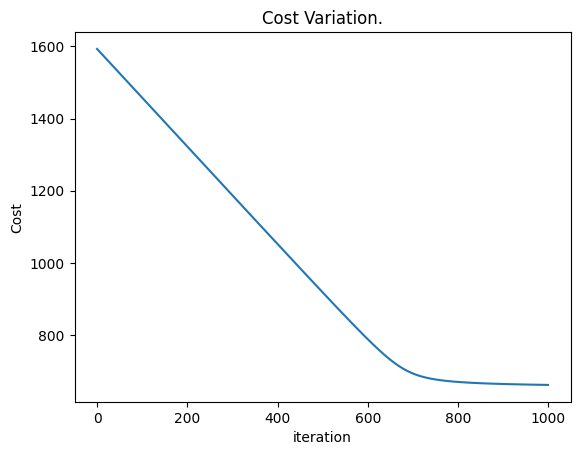

In [41]:
plt.plot(cost_history)
plt.title("Cost Variation.")
plt.xlabel("iteration")
plt.ylabel("Cost")
plt.show()